In [ ]:
import os
import numpy as np
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
from PIL import Image  # PIL is used to load the image
import matplotlib.pyplot as plt
import cv2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/datasets/QuadCore"
image_dir = os.path.join(dataset_path, "images")
label_dir = os.path.join(dataset_path, "labels")

In [ ]:
def displayImage(image_path):
  # Path to your image file in Google Drive
  image = Image.open(image_path)

  # Display the image using matplotlib
  plt.imshow(image)
  plt.axis('off')  # Hide axes for cleaner display
  plt.show()


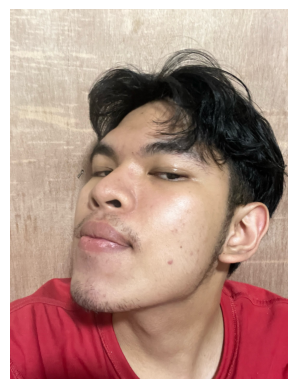

In [ ]:
displayImage('/content/drive/My Drive/datasets/QuadCore/images/00045f21-6cc59f0f-ba46-49fd-ae5a-874d5f8a135e.jpg')

In [ ]:
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print(f"TensorFlow is using GPU: {physical_devices[0]}")
else:
    print("No GPU available.")

TensorFlow is using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
SIZE = 256
image_size = (SIZE, SIZE)

In [ ]:
X = []
y_class = []
y_bbox = []
class_ids = set()

In [ ]:
for filename in os.listdir(image_dir):
    if filename.endswith((".jpg", ".png", ".jpeg", ".JPG")):
        image_path = os.path.join(image_dir, filename)
        label_path = os.path.join(label_dir, os.path.splitext(filename)[0] + ".txt")

        if not os.path.exists(label_path):
            continue

        # Load image
        img = cv2.imread(image_path)
        if img is None:
            continue
        img = cv2.resize(img, image_size)
        img = img / 255.0

        # Load annotation
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls = int(parts[0])
            bbox = list(map(float, parts[1:]))

            X.append(img)
            y_class.append(cls)
            y_bbox.append(bbox)
            class_ids.add(cls)

X = np.array(X, dtype=np.float32)

In [ ]:
# Map class IDs to indices
class_ids = sorted(list(class_ids))
class_to_idx = {cls: idx for idx, cls in enumerate(class_ids)}
num_classes = len(class_ids)

# # One-hot encode class labels
y_class = [class_to_idx[c] for c in y_class]
y_class = to_categorical(y_class, num_classes=num_classes)

y_bbox = np.array(y_bbox, dtype=np.float32)

In [ ]:
len(X)

854

In [ ]:
unique, counts = np.unique(np.argmax(y_class, axis=1), return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(210), np.int64(1): np.int64(200), np.int64(2): np.int64(232), np.int64(3): np.int64(212)}


In [ ]:
X_train, X_test, y_cls_train, y_cls_test, y_bbox_train, y_bbox_test = train_test_split(X, y_class, y_bbox, test_size=0.2, random_state=42)

In [ ]:
# Check distribution of classes in split
unique, counts = np.unique(np.argmax(y_class, axis=1), return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(210), np.int64(1): np.int64(200), np.int64(2): np.int64(232), np.int64(3): np.int64(212)}


In [ ]:
input_layer = layers.Input(shape=(SIZE, SIZE, 3))

x = layers.Conv2D(32, (3,3), activation='relu')(input_layer)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)

# Output 1: class probabilities
class_output = layers.Dense(num_classes, activation='softmax', name='class_output')(x)

# Output 2: bounding box (x_center, y_center, width, height)
bbox_output = layers.Dense(4, activation='sigmoid', name='bbox_output')(x)

model = models.Model(inputs=input_layer, outputs=[class_output, bbox_output])
model.compile(
    optimizer='adam',
    loss={'class_output': 'categorical_crossentropy', 'bbox_output': 'mse'},
    metrics={'class_output': 'accuracy'}
)

In [ ]:
model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 254, 254,  │        896 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_35    │ (None, 127, 127,  │          0 │ conv2d_60[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 125, 125,  │     18,496 │ max_pooling2d_35… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_36    │ (None, 62, 62,    │          0 │ conv2d_61[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 246016)    │          0 │ max_pooling2d_36… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 128)       │ 31,490,176 │ flatten_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 4)         │        516 │ dense_15[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        516 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,510,600 (120.20 MB)

 Trainable params: 31,510,600 (120.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience = 20,
    restore_best_weights=True,
    verbose=1,
    min_delta=0.0001,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # Reduce LR by half
    patience=10,        # Wait 3 epochs before reducing
    min_lr=1e-7,       # Don't go below this
    min_delta=0.0001,
    verbose=1
)

In [ ]:
model = models.Model(inputs=input_layer, outputs=[class_output, bbox_output])
# Initialize starting learning rate
initial_learning_rate = 0.00001
# Initialize optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=initial_learning_rate)
# Compile the model
model.compile(
    optimizer=optimizer,
    loss={'class_output': 'categorical_crossentropy', 'bbox_output': 'mse'},
    metrics={'class_output': 'accuracy'}
)

In [ ]:
history = model.fit(
    X_train,
    {'class_output': y_cls_train, 'bbox_output': y_bbox_train},
    epochs=1000,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - bbox_output_loss: 0.0115 - class_output_accuracy: 0.3432 - class_output_loss: 1.3409 - loss: 1.3525 - val_bbox_output_loss: 0.0077 - val_class_output_accuracy: 0.7536 - val_class_output_loss: 1.1357 - val_loss: 1.1444 - learning_rate: 1.0000e-05
Epoch 2/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - bbox_output_loss: 0.0104 - class_output_accuracy: 0.7295 - class_output_loss: 1.0742 - loss: 1.0857 - val_bbox_output_loss: 0.0074 - val_class_output_accuracy: 0.7826 - val_class_output_loss: 0.9683 - val_loss: 0.9644 - learning_rate: 1.0000e-05
Epoch 3/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - bbox_output_loss: 0.0097 - class_output_accuracy: 0.7552 - class_output_loss: 0.9367 - loss: 0.9463 - val_bbox_output_loss: 0.0080 - val_class_output_accuracy: 0.8696 - val_class_output_loss: 0.7849 - val_loss: 0.7986 - learning_rate: 1.0000e-05
Epoch 4/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - bbox_output_loss: 0.0101 - class_output_a

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)

# Separate class and bounding box predictions
y_cls_pred = y_pred[0]  # The class prediction (probabilities)
y_bbox_pred = y_pred[1]  # The bounding box prediction (x_center, y_center, width, height)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


In [ ]:
y_pred = model.predict(X_test)

# Separate the predictions
y_cls_pred = y_pred[0]  # Class probabilities
y_bbox_pred = y_pred[1]  # Bounding box predictions

# Find the predicted class for each sample
predicted_classes = np.argmax(y_cls_pred, axis=1)

# Compare with true class labels (just for class prediction)
true_classes = np.argmax(y_cls_test, axis=1)

# Calculate accuracy (for class prediction)
class_accuracy = np.mean(predicted_classes == true_classes)
print(f"Class prediction accuracy: {class_accuracy:.2f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Class prediction accuracy: 0.94


In [ ]:
# Print classification report
from sklearn.metrics import classification_report
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.88      0.95      0.92        40
           1       0.94      0.91      0.92        33
           2       0.96      0.94      0.95        51
           3       0.98      0.96      0.97        47

    accuracy                           0.94       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



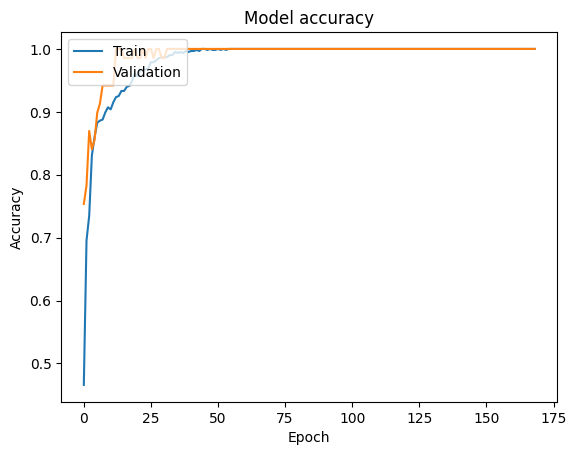

In [ ]:
# Plot history of steps
plt.plot(history.history['class_output_accuracy'])
plt.plot(history.history['val_class_output_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Get predicted classes
predicted_classes = np.argmax(y_cls_pred, axis=1)
true_classes = np.argmax(y_cls_test, axis=1)

# Find indices where predictions were wrong
classified_indices = np.where(predicted_classes == true_classes)[0]

# Plot a sample of 10 images
num_samples = 10
plt.figure(figsize=(15, 5))
for i, idx in enumerate(classified_indices[:num_samples]):
    plt.subplot(2, 5, i+1)
    img = X_test[idx]
    true_class = true_classes[idx]
    pred_class = predicted
    plt.imshow(img)
    plt.title(f'True: {true_class}, Predicted: {pred_class}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
'''for idx in misclassified_indices:
    img = X_test[idx]
    true_class = true_classes[idx]
    pred_class = predicted_classes[idx]

    # Get bounding box predictions
    bbox = y_bbox_pred[idx]

    # Convert normalized bbox to pixel coordinates
    x_center = bbox[0] * SIZE
    y_center = bbox[1] * SIZE
    width = bbox[2] * SIZE
    height = bbox[3] * SIZE

    # Calculate corners
    x1 = int(x_center - width/2)
    y1 = int(y_center - height/2)
    x2 = int(x_center + width/2)
    y2 = int(y_center + height/2)

    # Create a copy for drawing
    img_display = (img * 255).astype(np.uint8).copy()

    # Draw rectangle
    cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.figure(figsize=(2, 2))
    plt.imshow(img_display)
    plt.title(f'True: {true_class}, Predicted: {pred_class}')
    plt.axis('off')
    plt.show()'''

NameError: name 'np' is not defined

In [ ]:
model.save('model.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp53icej2j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  List[TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)]
Captures:
  138884216795984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138884216797136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138884216796944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138884216795216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138884216795024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138884216795792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138884216793680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138884216792528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138884216796752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138884216794256: T